<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/Week_6_Visualisasi_Data_Statistik_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Week 6 — Statistical Data Visualization  
## Fokus: Histogram, Density Plot, Boxplot, Scatterplot, dan Interpretasi

## Alur praktikum

Pada praktikum ini, Anda akan mempelajari **visualisasi data statistik** secara **bertahap, terurut, dan sistematis**.  
Fokus utama praktikum adalah memahami bagaimana grafik digunakan untuk:
- melihat **bentuk distribusi data**
- membandingkan **sebaran antar kelompok**
- mendeteksi **outlier**
- melihat **hubungan antar variabel**
- menyusun **interpretasi statistik yang benar**

Urutan pembelajaran:
1. Mengunggah dan membaca data `wine_dataset.csv`
2. Mengenal dataset secara singkat
3. Menyiapkan data untuk visualisasi
4. Membuat **histogram**
5. Membuat **density plot**
6. Membuat **boxplot**
7. Membuat **scatterplot**
8. Menulis **interpretasi visualisasi**
9. Mengerjakan latihan dan tugas Week 6

## Pengetahuan prasyarat
- konsep data dan variabel
- perbedaan data numerik dan kategorik
- penggunaan dasar `pandas`
- penggunaan dasar `matplotlib` dan `seaborn`

## 1. Import library
Library yang digunakan:
- `pandas` untuk membaca dan mengolah data tabel
- `numpy` untuk perhitungan numerik
- `matplotlib` dan `seaborn` untuk visualisasi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")

## 2. Upload file `wine_dataset.csv` langsung dari komputer
- Klik tombol **Choose Files**
- Pilih file **`wine_dataset.csv`** dari komputer
- Jika tidak ingin upload manual, notebook ini juga menyediakan **fallback** ke file bawaan

In [ ]:
# Upload file dari komputer (khusus Google Colab)
try:
    from google.colab import files
    uploaded = files.upload()
    print("File yang berhasil diupload:", list(uploaded.keys()))
except Exception as e:
    print("Mode non-Colab atau upload dilewati.")
    print("Pesan:", e)

Saving wine_dataset.csv to wine_dataset.csv
File yang berhasil diupload: ['wine_dataset.csv']


## 3. Membaca file CSV
Bagian ini menggunakan `pandas.read_csv()`.
Notebook akan mencoba membaca file dari beberapa lokasi yang umum dipakai di Google Colab.

In [ ]:
from pathlib import Path

possible_paths = [
    Path("/content/wine_dataset.csv"),   # lokasi umum setelah upload di Colab
    Path("wine_dataset.csv"),            # folder kerja aktif
    Path("/mnt/data/wine_dataset.csv"),  # fallback bawaan notebook ini
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("File wine_dataset.csv tidak ditemukan. Silakan upload terlebih dahulu.")

df = pd.read_csv(csv_path)
print("Dataset berhasil dibaca dari:", csv_path)
print("Ukuran dataset:", df.shape)

Dataset berhasil dibaca dari: /content/wine_dataset.csv
Ukuran dataset: (178, 14)


## 4. Mengenal dataset secara singkat

Dataset yang digunakan adalah **Wine Dataset**.  
Setiap baris merepresentasikan **satu sampel wine**, sedangkan setiap kolom numerik menggambarkan karakteristik kimia dari wine tersebut.

### Mengapa menggunakan dataset ini?
- memiliki banyak **variabel numerik** yang cocok untuk histogram, density plot, boxplot, dan scatterplot
- memiliki **kelompok kelas wine** (`wine_class`) sehingga dapat digunakan untuk perbandingan antar kelompok
- ukuran dataset tidak terlalu besar sehingga cocok untuk praktikum dasar visualisasi statistik
- pola distribusi dan hubungan variabel cukup jelas untuk keperluan interpretasi

### Tampilkan beberapa baris data
Perhatikan nama variabel, bentuk data, dan kolom kategorik yang tersedia.

In [ ]:
df.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,class_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,class_0


### Lihat nama kolom
Langkah ini membantu mengenali variabel yang tersedia.

In [ ]:
list(df.columns)

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 'wine_class']

### Lihat tipe data
- **numerik** → dapat divisualisasikan sebagai histogram, density plot, boxplot, dan scatterplot
- **kategorik** → dapat digunakan sebagai pembeda kelompok

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  wine_

## 5. Pembersihan data sederhana
Untuk visualisasi yang baik, kita pastikan:
1. nama kolom rapi
2. tipe data sesuai
3. missing values diperiksa

In [ ]:
df = df.copy()

# Rapikan nama kolom
df.columns = [c.strip().lower().replace(" ", "_").replace("/", "_per_") for c in df.columns]

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_per_od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


### Cek missing values
Missing value perlu dicek karena dapat memengaruhi visualisasi dan interpretasi.

In [ ]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_table

,missing_count,missing_percent
alcohol,0,0.0
malic_acid,0,0.0
ash,0,0.0
alcalinity_of_ash,0,0.0
magnesium,0,0.0
total_phenols,0,0.0
flavanoids,0,0.0
nonflavanoid_phenols,0,0.0
proanthocyanins,0,0.0
color_intensity,0,0.0


### Tentukan kolom numerik dan kolom kategorik

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print("Kolom numerik:")
for col in numeric_cols:
    print("-", col)

print("\nKolom kategorik:")
for col in categorical_cols:
    print("-", col)

Kolom numerik:
- alcohol
- malic_acid
- ash
- alcalinity_of_ash
- magnesium
- total_phenols
- flavanoids
- nonflavanoid_phenols
- proanthocyanins
- color_intensity
- hue
- od280_per_od315_of_diluted_wines
- proline

Kolom kategorik:
- wine_class


## 6. Menentukan variabel yang akan dipakai pada praktikum
Pada notebook ini digunakan beberapa variabel berikut:
- **`alcohol`** untuk melihat distribusi satu variabel
- **`flavanoids`** untuk membandingkan distribusi antar kelompok
- **`color_intensity`** dan **`alcohol`** untuk melihat hubungan dua variabel
- **`wine_class`** sebagai variabel kategorik pembeda kelompok

In [ ]:
selected_cols = ["alcohol", "flavanoids", "color_intensity", "wine_class"]
df[selected_cols].head()

,alcohol,flavanoids,color_intensity,wine_class
0,14.23,3.06,5.64,class_0
1,13.20,2.76,4.38,class_0
2,13.16,3.24,5.68,class_0
3,14.37,3.49,7.80,class_0
4,13.24,2.69,4.32,class_0


## 7. Statistik ringkas sebelum visualisasi
Sebelum membuat grafik, lihat ringkasan statistik agar interpretasi visual lebih terarah.

In [ ]:
df[["alcohol", "flavanoids", "color_intensity"]].describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### Catatan penting
Visualisasi statistik **bukan sekadar membuat grafik**.  
Setiap grafik harus dibaca dengan memperhatikan:
- pusat distribusi
- sebaran
- kemencengan
- outlier
- perbedaan antar kelompok
- pola hubungan antar variabel

# Bagian A — Histogram
Histogram digunakan untuk melihat **distribusi frekuensi** suatu variabel numerik.

Hal yang perlu diperhatikan saat membaca histogram:
- apakah distribusi **simetris** atau **miring**
- apakah data terkonsentrasi di tengah atau menyebar
- apakah ada indikasi **lebih dari satu puncak**
- di mana posisi **mean** dan **median**

## A1. Histogram untuk variabel `alcohol`
Pada grafik ini akan ditambahkan garis:
- **merah** = mean
- **hijau** = median

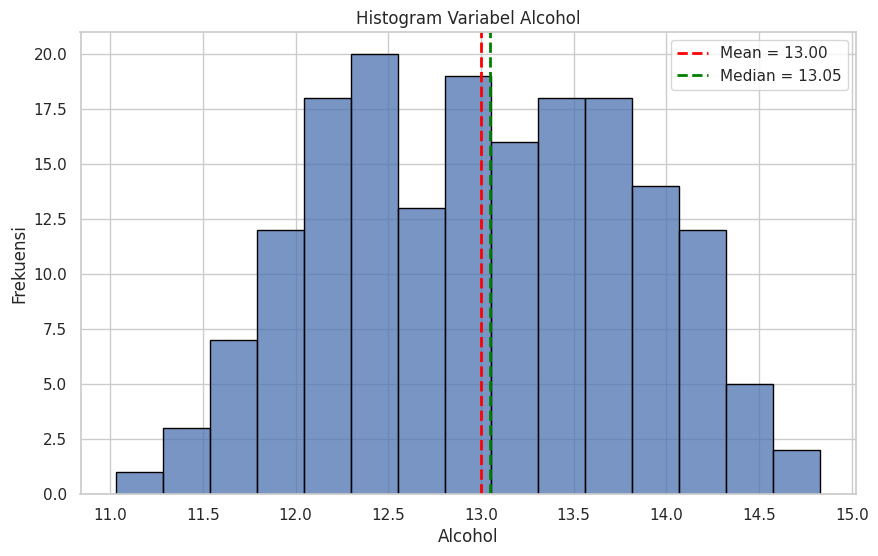

In [ ]:
x = df["alcohol"].dropna()

mean_x = x.mean()
median_x = x.median()

plt.figure(figsize=(10, 6))
sns.histplot(x, bins=15, kde=False, edgecolor="black")
plt.axvline(mean_x, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_x:.2f}")
plt.axvline(median_x, color="green", linestyle="--", linewidth=2, label=f"Median = {median_x:.2f}")
plt.title("Histogram Variabel Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

## A2. Interpretasi histogram
Gunakan pertanyaan berikut saat membaca grafik:
1. Apakah distribusi `alcohol` cenderung simetris atau miring?
2. Apakah mean dan median berdekatan atau berjauhan?
3. Apakah ada rentang nilai yang sangat dominan?
4. Apakah ada indikasi data ekstrem?

In [ ]:
print("Mean alcohol  :", round(df["alcohol"].mean(), 3))
print("Median alcohol:", round(df["alcohol"].median(), 3))
print("Min alcohol   :", round(df["alcohol"].min(), 3))
print("Max alcohol   :", round(df["alcohol"].max(), 3))

Mean alcohol  : 13.001
Median alcohol: 13.05
Min alcohol   : 11.03
Max alcohol   : 14.83


### Contoh interpretasi
- Histogram menunjukkan bagaimana nilai `alcohol` tersebar pada seluruh sampel wine.
- Jika batang banyak terkonsentrasi di sekitar nilai tengah, maka mayoritas sampel berada pada rentang tersebut.
- Jika mean dan median cukup dekat, distribusi cenderung relatif seimbang.
- Jika salah satu sisi lebih panjang, distribusi cenderung miring ke kiri atau ke kanan.

###Interpretasi singkat berdasarkan plot histogram
Histogram variabel alcohol menunjukkan distribusi yang relatif simetris dengan pusat data di sekitar 13.0. Nilai mean dan median yang hampir sama menandakan bahwa data tidak menceng secara signifikan. Sebagian besar observasi berada pada kisaran 12.0–14.0 dan tidak tampak outlier ekstrem.

## Checkpoint pemahaman 1
Tuliskan dengan kalimat Anda sendiri:
- bentuk distribusi `alcohol`
- posisi mean terhadap median
- apakah ada indikasi skewness

# Bagian B — Density Plot
Density plot digunakan untuk melihat **bentuk distribusi yang lebih halus** dibanding histogram.

Density plot sangat berguna untuk:
- membandingkan bentuk distribusi beberapa kelompok
- melihat puncak distribusi
- melihat tumpang tindih antar kelompok

## B1. Density plot `alcohol` berdasarkan `wine_class`

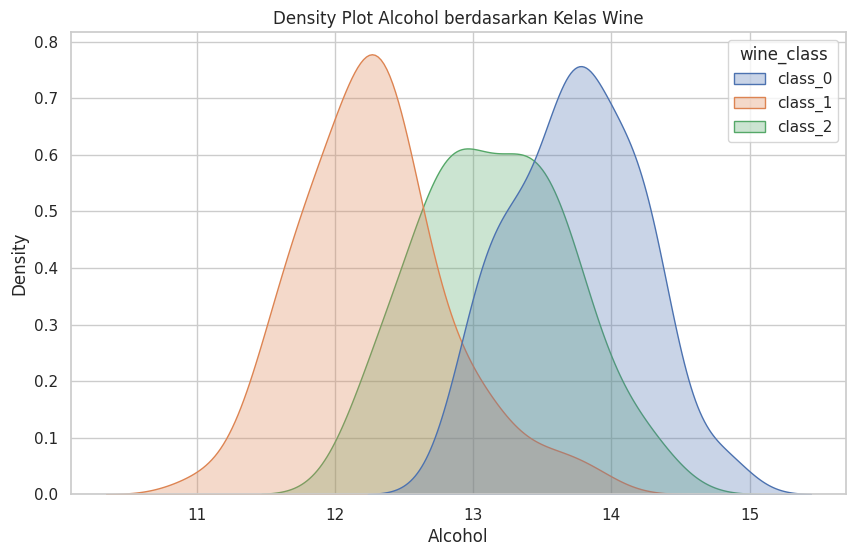

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="alcohol", hue="wine_class", fill=True, common_norm=False, alpha=0.3)
plt.title("Density Plot Alcohol berdasarkan Kelas Wine")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.show()

## B2. Interpretasi density plot
Saat membaca density plot perhatikan:
- puncak distribusi masing-masing kelompok
- apakah kurva saling tumpang tindih
- kelompok mana yang cenderung memiliki nilai lebih tinggi atau lebih rendah

In [ ]:
df.groupby("wine_class")["alcohol"].agg(["count", "mean", "median", "std"]).round(3)

,count,mean,median,std
wine_class,,,,
class_0,59,13.745,13.750,0.462
class_1,71,12.279,12.290,0.538
class_2,48,13.154,13.165,0.530


### Contoh interpretasi
- Jika suatu kurva bergeser lebih ke kanan, kelompok tersebut cenderung memiliki nilai `alcohol` lebih tinggi.
- Jika dua kurva banyak bertumpang tindih, maka kedua kelompok memiliki distribusi yang mirip pada variabel tersebut.
- Jika puncak kurva tajam, data lebih terkonsentrasi pada rentang tertentu.
- Jika kurva lebih lebar, variasi datanya cenderung lebih besar.

###Interpretasi singkat berdasarkan denstiy plot
Density plot menunjukkan bahwa distribusi alcohol berbeda antar kelas wine. class_1 cenderung memiliki kadar alcohol paling rendah, class_2 berada pada tingkat menengah, dan class_0 memiliki kadar alcohol paling tinggi. Walaupun ada sedikit overlap, variabel alcohol cukup informatif untuk membedakan kelas wine.

# Bagian C — Boxplot
Boxplot digunakan untuk merangkum distribusi data berdasarkan:
- median
- kuartil 1 (Q1)
- kuartil 3 (Q3)
- IQR
- outlier

Boxplot sangat efektif untuk:
- membandingkan kelompok
- melihat variasi
- mendeteksi outlier

## C1. Boxplot `flavanoids` berdasarkan `wine_class`

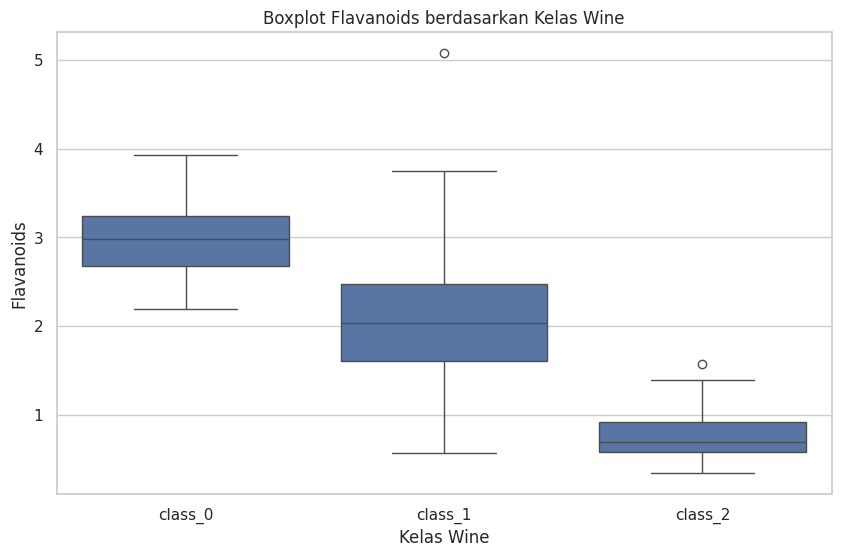

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="wine_class", y="flavanoids")
plt.title("Boxplot Flavanoids berdasarkan Kelas Wine")
plt.xlabel("Kelas Wine")
plt.ylabel("Flavanoids")
plt.show()

## C2. Ringkasan numerik per kelompok
Ringkasan ini membantu menjelaskan apa yang terlihat pada boxplot.

In [ ]:
df.groupby("wine_class")["flavanoids"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
wine_class,,,,,,,,
class_0,59.0,2.982,0.397,2.19,2.680,2.980,3.245,3.93
class_1,71.0,2.081,0.706,0.57,1.605,2.030,2.475,5.08
class_2,48.0,0.781,0.294,0.34,0.580,0.685,0.920,1.57


## C3. Interpretasi boxplot
Hal yang perlu dibaca dari boxplot:
1. **median** masing-masing kelompok
2. lebar kotak sebagai gambaran **IQR**
3. panjang whisker sebagai gambaran sebaran tambahan
4. titik di luar whisker sebagai **outlier**

### Contoh interpretasi
- Kelompok dengan median lebih tinggi cenderung memiliki nilai pusat yang lebih besar.
- Kotak yang lebih tinggi menunjukkan variasi tengah data yang lebih besar.
- Adanya titik di luar whisker menunjukkan pengamatan yang relatif ekstrem menurut aturan boxplot.
- Jika median tidak berada di tengah kotak, distribusi dalam kelompok tersebut bisa tidak simetris.

###Interpretasi singkat berdasarkan boxplot
Boxplot memperlihatkan bahwa nilai flavanoids berbeda jelas antar kelas wine. class_0 memiliki median tertinggi, class_1 berada di tengah dengan variasi lebih besar, dan class_2 memiliki median paling rendah. Variabel flavanoids sangat baik untuk membedakan kelas wine.

## Checkpoint pemahaman 2
Jawab pertanyaan berikut:
- kelas wine mana yang memiliki median `flavanoids` tertinggi?
- kelas mana yang paling homogen?
- apakah terdapat outlier?

# Bagian D — Scatterplot
Scatterplot digunakan untuk melihat **hubungan antara dua variabel numerik**.

Scatterplot membantu kita membaca:
- arah hubungan (positif/negatif)
- kekuatan hubungan
- pola linier atau nonlinier
- pemisahan kelompok
- outlier dua dimensi

## D1. Scatterplot `alcohol` vs `color_intensity`
Titik akan diberi warna berdasarkan `wine_class`.

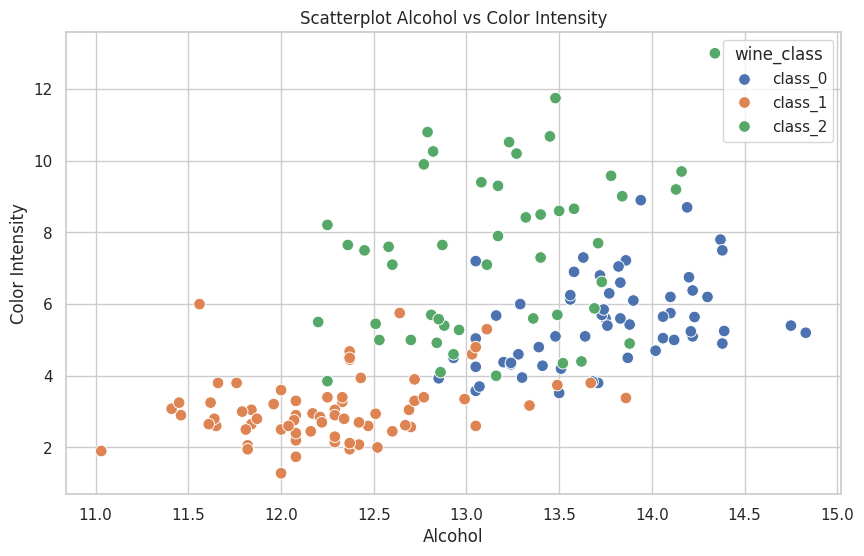

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue="wine_class", s=70)
plt.title("Scatterplot Alcohol vs Color Intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.show()

## D2. Korelasi sederhana dua variabel

In [ ]:
corr_val = df[["alcohol", "color_intensity"]].corr().iloc[0, 1]
print("Korelasi Pearson alcohol vs color_intensity =", round(corr_val, 3))

Korelasi Pearson alcohol vs color_intensity = 0.546


## D3. Interpretasi scatterplot
Perhatikan hal berikut:
- apakah titik membentuk kecenderungan naik atau turun
- apakah hubungan terlihat kuat atau lemah
- apakah kelompok kelas wine saling terpisah
- apakah ada titik yang sangat jauh dari pola umum

### Contoh interpretasi
- Jika titik-titik cenderung naik dari kiri bawah ke kanan atas, hubungan bersifat positif.
- Jika titik-titik menyebar sangat luas tanpa pola jelas, hubungan cenderung lemah.
- Jika warna kelompok membentuk gugus terpisah, variabel tersebut membantu membedakan kelas.
- Scatterplot tidak otomatis membuktikan sebab-akibat; grafik ini hanya menunjukkan pola asosiasi.

###Interpretasi singkat berdasarkan scatterplot
Scatterplot menunjukkan kecenderungan hubungan positif antara alcohol dan color intensity. Selain itu, terlihat pola pengelompokan berdasarkan kelas wine: class_1 cenderung berada pada nilai rendah, class_0 pada alcohol tinggi dengan intensity menengah, dan class_2 pada color intensity yang lebih tinggi. Kedua variabel ini cukup baik untuk membantu membedakan kelas wine.

# Bagian E — Visualisasi tambahan untuk pendalaman interpretasi
Bagian ini membantu mahasiswa membandingkan beberapa visualisasi sekaligus pada variabel yang sama atau serupa.

## E1. Histogram + KDE untuk `flavanoids`
Kombinasi ini memudahkan membaca bentuk distribusi sekaligus kurva kepadatan.

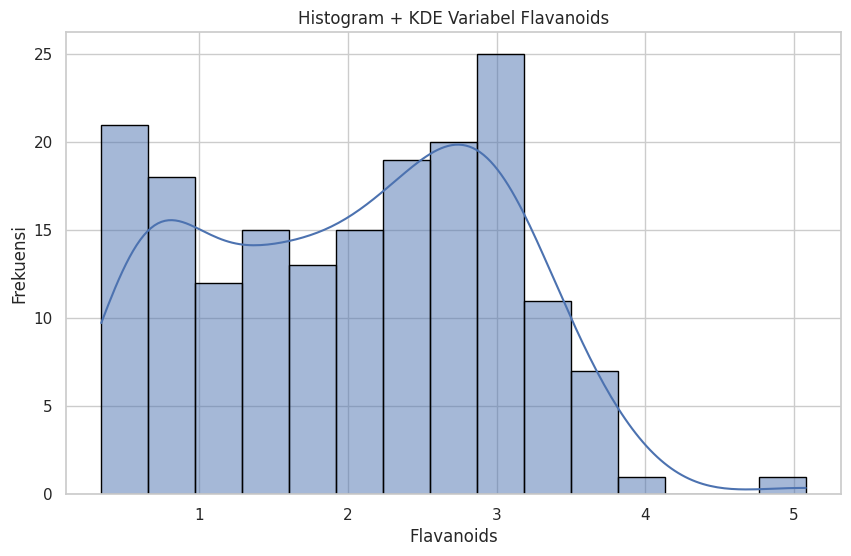

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["flavanoids"], bins=15, kde=True, edgecolor="black")
plt.title("Histogram + KDE Variabel Flavanoids")
plt.xlabel("Flavanoids")
plt.ylabel("Frekuensi")
plt.show()

## E2. Scatterplot lain: `flavanoids` vs `color_intensity`
Visualisasi ini digunakan untuk melihat apakah pasangan variabel lain memberi pola pemisahan kelompok yang lebih jelas.

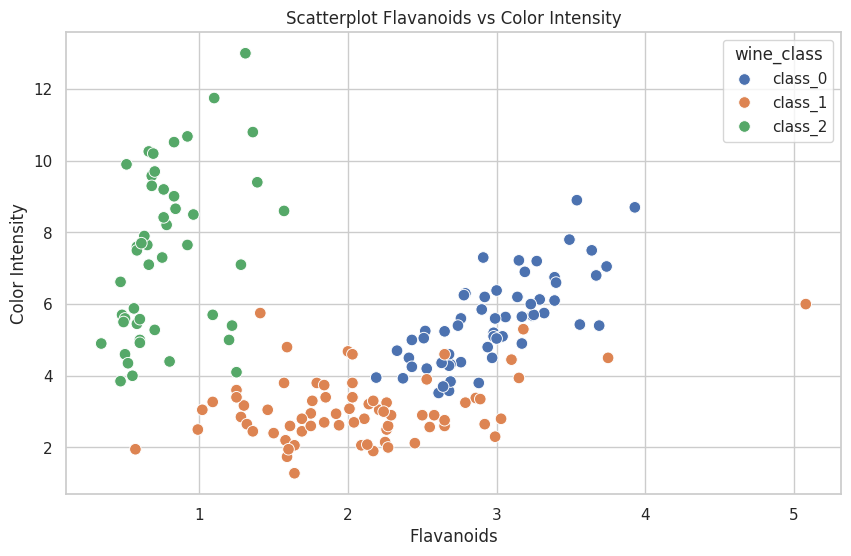

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="flavanoids", y="color_intensity", hue="wine_class", s=70)
plt.title("Scatterplot Flavanoids vs Color Intensity")
plt.xlabel("Flavanoids")
plt.ylabel("Color Intensity")
plt.show()

# Bagian F — Ringkasan interpretasi visualisasi
Berikut cara menyusun interpretasi yang baik.

## Format interpretasi yang disarankan
Setiap interpretasi minimal memuat:
1. **apa yang ditampilkan grafik**
2. **pola utama yang terlihat**
3. **arti statistik dari pola tersebut**
4. **kesimpulan singkat**

## Contoh template untuk interpretasi dari hasil visualisasi:

### Histogram
“Histogram variabel ... menunjukkan bahwa distribusi data cenderung ..., dengan konsentrasi data terbesar pada rentang .... Posisi mean yang ... terhadap median mengindikasikan ....”

### Density plot
“Density plot menunjukkan bahwa kelas ... cenderung memiliki nilai ... dibanding kelas ..., terlihat dari kurva yang bergeser ke .... Tumpang tindih kurva menunjukkan bahwa ....”

### Boxplot
“Boxplot memperlihatkan bahwa median variabel ... pada kelas ... lebih tinggi/rendah dibanding kelas lain. Lebar kotak menunjukkan bahwa variasi pada kelas ... lebih besar/kecil. Terdapat/tidak terdapat outlier pada ....”

### Scatterplot
“Scatterplot antara ... dan ... menunjukkan hubungan yang cenderung .... Pola sebaran titik mengindikasikan bahwa hubungan tersebut ... kuat/lemah. Pemisahan warna menunjukkan bahwa ....”

### Buat interpretasi singkat dari:
Histogram + KDE Variabel Flavanoids?

Scatterplot Flavanoids vs Color Intensity?

# Bagian G — Latihan mandiri
Kerjakan latihan berikut langsung pada notebook ini.

## Latihan 1
Buat histogram untuk salah satu variabel numerik lain selain `alcohol`, lalu tuliskan interpretasinya.

In [ ]:
# Tulis kode Anda di sini

## Latihan 2
Buat density plot berdasarkan `wine_class` untuk variabel `color_intensity`, lalu jelaskan perbedaan antar kelas.

In [ ]:
# Tulis kode Anda di sini

## Latihan 3
Buat boxplot untuk satu variabel numerik lain berdasarkan `wine_class`, lalu identifikasi median, IQR, dan outlier.

In [ ]:
# Tulis kode Anda di sini

## Latihan 4
Buat scatterplot dari dua variabel numerik pilihan Anda, lalu jelaskan arah dan kekuatan hubungan yang terlihat.

In [ ]:
# Tulis kode Anda di sini

## Aktivitas diskusi kelas
Diskusikan pertanyaan berikut:
1. Mengapa histogram dan density plot sama-sama berguna untuk melihat distribusi?
2. Dalam kondisi apa boxplot lebih informatif daripada histogram?
3. Mengapa scatterplot penting untuk eksplorasi awal sebelum pemodelan statistik?
4. Apakah visualisasi selalu cukup untuk mengambil kesimpulan? Jelaskan.

# Bagian H — Tugas Week 6

Gunakan **1 dataset publik** yang Anda pilih sendiri, lalu kerjakan analisis visualisasi statistik dengan tahapan berikut.

## Soal

### 1. Jelaskan dataset yang Anda gunakan
Jelaskan:
- nama dataset
- link sumber
- periode data
- unit analisis
- arti variabel utama

### 2. Muat dataset ke Python menggunakan `pandas`
Tampilkan:
- `shape`
- `head()`
- `info()`
- ringkasan variabel yang akan divisualisasikan

### 3. Lakukan pemeriksaan kualitas data sederhana
Periksa:
- missing values
- data duplikat
- tipe data
- variabel numerik dan kategorik

### 4. Buat visualisasi berikut
Minimal buat:
- **1 histogram**
- **1 density plot**
- **1 boxplot**
- **1 scatterplot**

### 5. Tuliskan interpretasi
Untuk **setiap visualisasi**, jelaskan:
- pola utama
- bentuk distribusi atau hubungan
- indikasi outlier atau overlap
- kesimpulan statistik singkat

### 6. Buat kesimpulan umum
Tuliskan ringkasan temuan dari keseluruhan visualisasi.

## Rubrik Penilaian Tugas Week 6
- Ketepatan memilih dataset: **10%**
- Kebenaran membaca dan menyiapkan data: **20%**
- Ketepatan pembuatan visualisasi: **30%**
- Kualitas interpretasi statistik: **30%**
- Kerapian notebook dan dokumentasi: **10%**

## Kesimpulan
Pada Week 6, Anda telah mempelajari empat visualisasi statistik dasar yang sangat penting:
- **Histogram** untuk melihat distribusi frekuensi
- **Density plot** untuk melihat bentuk distribusi yang lebih halus
- **Boxplot** untuk melihat median, sebaran, dan outlier
- **Scatterplot** untuk melihat hubungan antar variabel

Kemampuan utama yang harus dikuasai bukan hanya membuat grafik, tetapi juga **menginterpretasikan grafik secara statistik, akurat, dan logis**.